# Exploratory Data Analysis (EDA)

This notebook presents an exploratory analysis of NBA three-point shooting trends from the 1996-97 season to 2019-20. The goal is to identify patterns in three-point attempts, scoring, and pace over time.

## Data Collection and Processing

The dataset used in this analysis combines multiple sources:

- NBA Three-Point Shooting dataset (Kaggle)
- Additional statistics such as Pace and Points Per Game collected from NBA official sources

The datasets were merged based on season information to create a unified dataset containing:

- Three-point attempts (3PA)
- Three-point percentage (3P%)
- Three-point share of total scoring
- Points per game (PTS)
- Pace

The final processed dataset contains 24 seasons (1996–2020) and was cleaned to remove missing values and ensure consistency across features.

## 1. Imports

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data

In [13]:
df = pd.read_csv("DATA/processed/final_dataset.csv")

## 3. Data Overview

In [14]:
df.head()

,Season,3PM,3PA,3P_percent,ThreePointShare,PTS_per_game,Pace
0,1996-97,6.044828,16.79310,35.96207,18.735517,96.9,90.1
1,1997-98,4.403448,12.71379,34.37931,13.875862,95.6,90.3
2,1998-99,4.455172,13.16552,33.61724,14.546897,91.6,88.9
3,1999-00,4.837931,13.71724,35.28966,14.851720,97.5,93.1
4,2000-01,4.841379,13.70690,35.18276,15.277241,94.8,91.3


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Season           24 non-null     str    
 1   3PM              24 non-null     float64
 2   3PA              24 non-null     float64
 3   3P_percent       24 non-null     float64
 4   ThreePointShare  24 non-null     float64
 5   PTS_per_game     24 non-null     float64
 6   Pace             24 non-null     float64
dtypes: float64(6), str(1)
memory usage: 1.4 KB


In [16]:
df.describe()

,3PM,3PA,3P_percent,ThreePointShare,PTS_per_game,Pace
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,6.880991,19.333262,35.335820,20.339231,99.425000,92.858333
std,2.170834,5.965665,0.656248,5.309485,5.077165,3.044156
min,4.403448,12.713790,33.617240,13.875862,91.600000,88.900000
25%,5.206034,14.879310,34.903401,16.552590,96.125000,90.850000
50%,6.423334,18.058335,35.308335,18.950424,98.400000,91.950000
75%,7.782500,21.752502,35.767502,23.073250,100.550000,93.900000
max,12.200000,34.100000,36.543330,32.700000,111.800000,100.300000


## 4. Time Series Visualizations

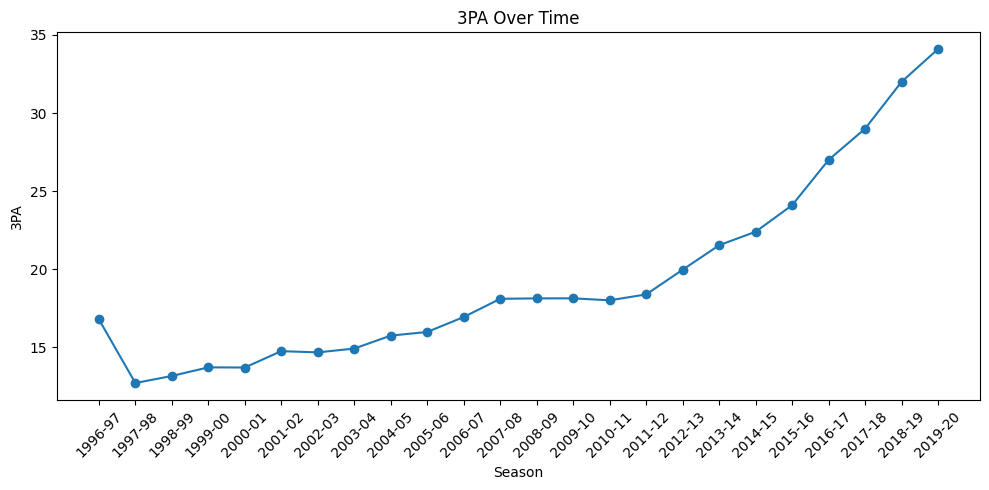

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(df["Season"], df["3PA"], marker="o")
plt.title("3PA Over Time")
plt.xlabel("Season")
plt.ylabel("3PA")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

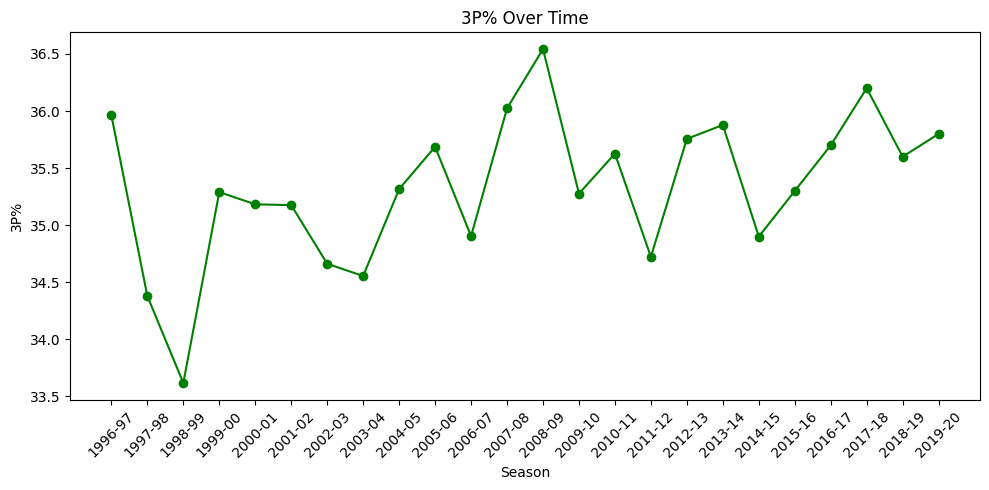

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(df["Season"], df["3P_percent"], marker="o", color="green")
plt.title("3P% Over Time")
plt.xlabel("Season")
plt.ylabel("3P%")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

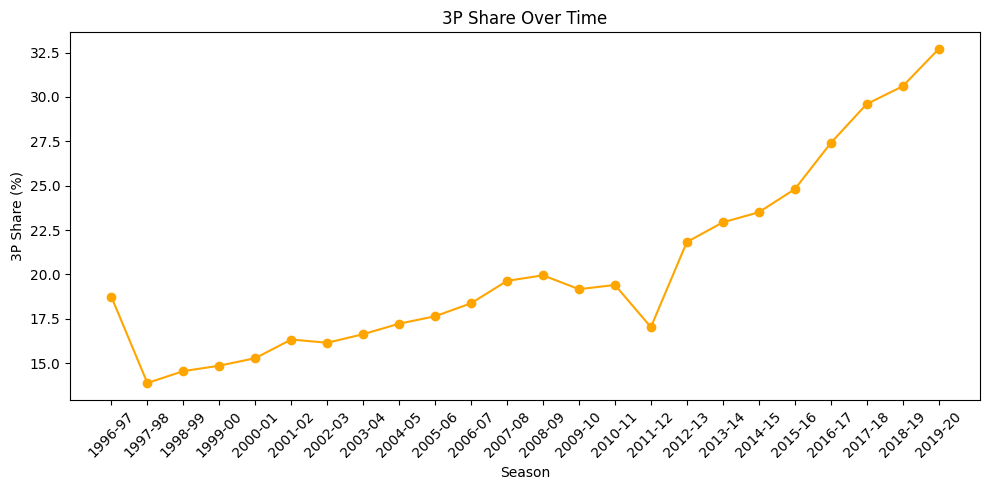

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(df["Season"], df["ThreePointShare"], marker="o", color="orange")
plt.title("3P Share Over Time")
plt.xlabel("Season")
plt.ylabel("3P Share (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

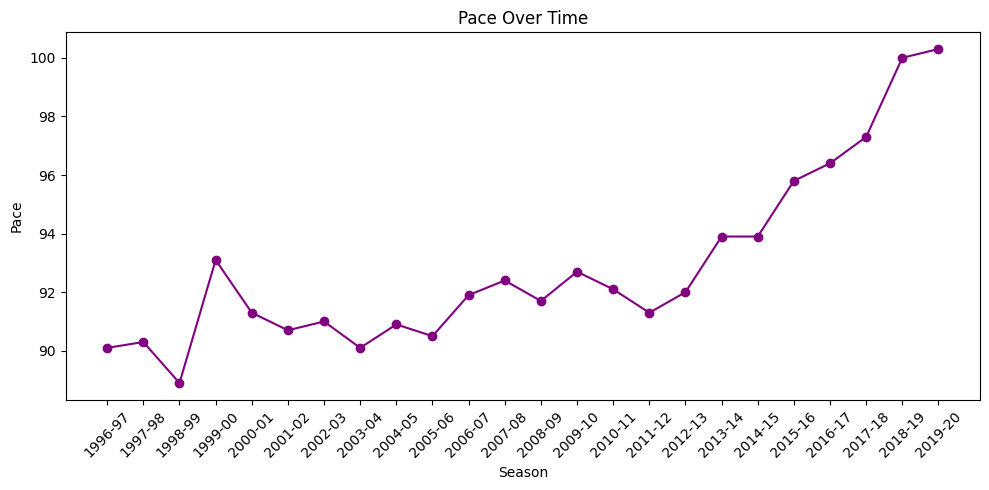

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(df["Season"], df["Pace"], marker="o", color="purple")
plt.title("Pace Over Time")
plt.xlabel("Season")
plt.ylabel("Pace")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Correlation Analysis

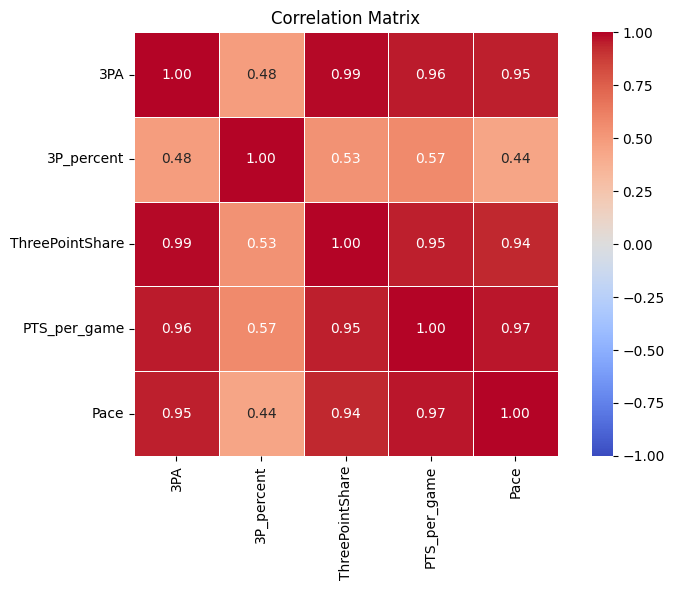

In [21]:
corr = df[["3PA", "3P_percent", "ThreePointShare", "PTS_per_game", "Pace"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Correlation Interpretation

The heatmap shows strong positive correlations between three-point attempts (3PA), three-point share, and points per game.

In particular, 3PA and PTS per game exhibit a very high correlation, suggesting that increased three-point shooting volume is strongly associated with higher scoring.

Pace also shows a moderate positive correlation with scoring, indicating that faster gameplay contributes to increased offensive output.

These findings support the hypothesis that modern NBA scoring is heavily influenced by three-point shooting strategies.

## 6. Scatter Plot: 3PA vs Scoring

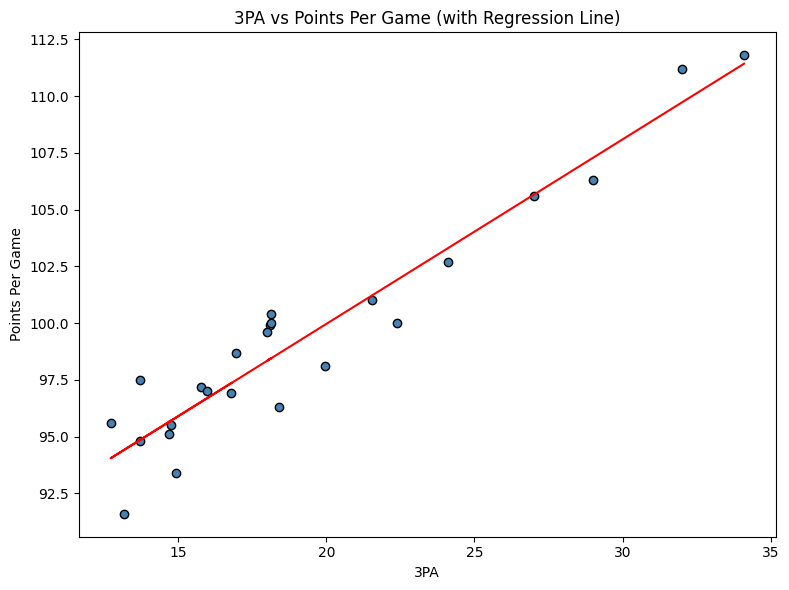

In [22]:
import numpy as np

x = df["3PA"]
y = df["PTS_per_game"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color="steelblue", edgecolors="black")
plt.plot(x, m*x + b, color="red")
plt.xlabel("3PA")
plt.ylabel("Points Per Game")
plt.title("3PA vs Points Per Game (with Regression Line)")
plt.tight_layout()
plt.show()

## 7. EDA Commentary

The analysis reveals a clear upward trend in three-point attempts (3PA) over time, with a noticeable acceleration after approximately 2015, suggesting a structural shift in the game.

The share of three-point scoring in total points has also increased steadily, indicating a growing reliance on perimeter shooting strategies.

Points per game (PTS) have increased over time, reflecting overall scoring growth in the league.

Pace has also increased, suggesting that faster gameplay contributes to higher scoring levels.

The correlation analysis shows a very strong positive relationship between three-point attempts and points per game. This indicates that increased three-point shooting is strongly associated with increased scoring.

However, the simultaneous increase in pace suggests that scoring growth is likely driven by multiple factors, not solely by three-point shooting. Further hypothesis testing will be conducted to determine statistical significance.